# 2024 SHED Survey - Racial/Ethnic Comparison Analysis

Survey of Household Economics and Decisionmaking - Federal Reserve

**Focus:** Comparison across racial/ethnic groups (White, Hispanic, Black, Asian)

**Sample:** Non-retired respondents only

In [63]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [64]:
# Load the optimized dataset (non-retired, excluding 'Other' race category)
df = pd.read_csv('data_optimized.csv', low_memory=False)

print(f"Dataset loaded: {len(df):,} respondents, {len(df.columns)} variables")
print(f"\nRacial/Ethnic breakdown:")
print(df['race_5cat'].value_counts())

Dataset loaded: 7,858 respondents, 385 variables

Racial/Ethnic breakdown:
race_5cat
White       5192
Hispanic    1300
Black        965
Asian        401
Name: count, dtype: int64


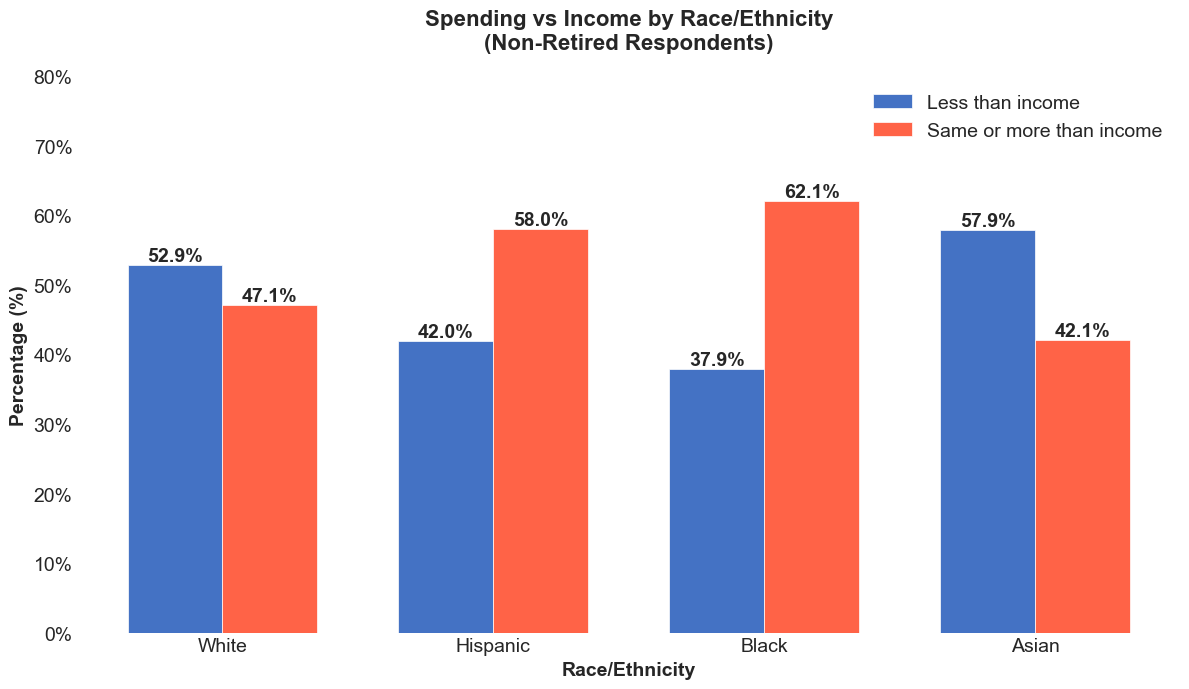


Spending vs Income by Race/Ethnicity:
I20_grouped  Less than your income  Same or more than your income
race_5cat                                                        
White                        52.90                          47.10
Hispanic                     42.00                          58.00
Black                        37.90                          62.10
Asian                        57.90                          42.10

Total respondents included: 7,858


In [65]:
# Chart 1: Race/Ethnicity vs Spending Behavior (I20)
# Filter for valid I20 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart = df[df['race_5cat'].isin(race_groups) & df['I20'].notna()].copy()

# Create a new spending category combining "same" and "more"
df_chart['I20_grouped'] = df_chart['I20'].apply(
    lambda x: 'Less than your income' if x == 'Less than your income' else 'Same or more than your income'
)

# Create crosstab with percentages
spending_by_race = pd.crosstab(df_chart['race_5cat'], df_chart['I20_grouped'], normalize='index') * 100

# Ensure the columns are in the desired order
spending_order = ['Less than your income', 'Same or more than your income']
spending_by_race = spending_by_race[spending_order]

# Reindex to ensure race groups are in order
spending_by_race = spending_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.35

# Define simple, distinguishable colors
colors = ['#4472C4', '#FF6347']  # Blue for "Less", Red-orange for "Same or more"

# Create bars for each spending category
bars1 = ax.bar(x - width/2, spending_by_race[spending_order[0]], width, 
               label='Less than income', color=colors[0], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, spending_by_race[spending_order[1]], width, 
               label='Same or more than income', color=colors[1], edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Spending vs Income by Race/Ethnicity\n(Non-Retired Respondents)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-80%
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSpending vs Income by Race/Ethnicity:")
print("="*60)
print(spending_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart):,}")

---
## Racial/Ethnic Comparison Visualizations

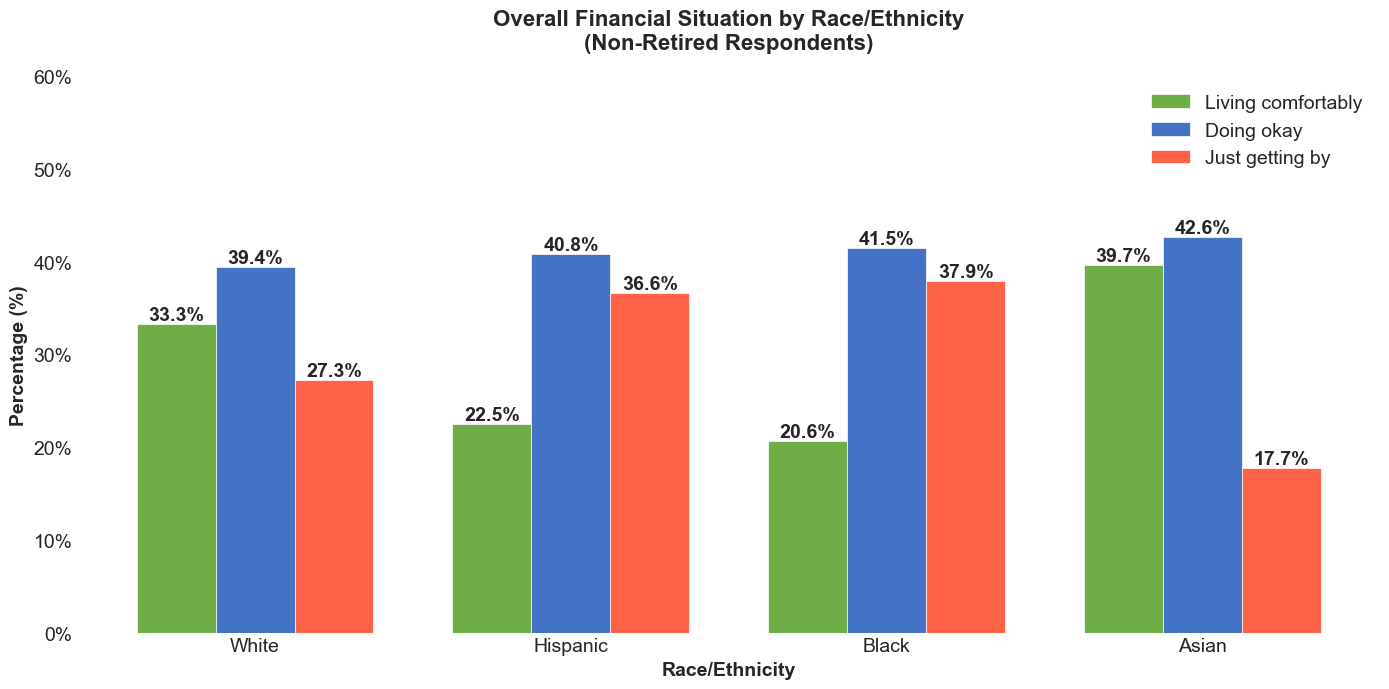


Overall Financial Situation by Race/Ethnicity:
B2_grouped  Living comfortably  Doing okay  Just getting by
race_5cat                                                  
White                    33.30       39.40            27.30
Hispanic                 22.50       40.80            36.60
Black                    20.60       41.50            37.90
Asian                    39.70       42.60            17.70

Total respondents included: 7,858


In [66]:
# Chart 2: Race/Ethnicity vs Overall Financial Situation (B2)
# Filter for valid B2 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart2 = df[df['race_5cat'].isin(race_groups) & df['B2'].notna()].copy()

# Create a new B2 category combining "just getting by" and "finding it difficult"
df_chart2['B2_grouped'] = df_chart2['B2'].apply(
    lambda x: 'Just getting by' if x in ['Just getting by', 'Finding it difficult to get by'] 
    else x
)

# Create crosstab with percentages
financial_by_race = pd.crosstab(df_chart2['race_5cat'], df_chart2['B2_grouped'], normalize='index') * 100

# Define the order of financial situation categories (from best to worst)
financial_order = ['Living comfortably', 'Doing okay', 'Just getting by']

# Filter to only include categories that exist in the data
financial_order = [cat for cat in financial_order if cat in financial_by_race.columns]
financial_by_race = financial_by_race[financial_order]

# Reindex to ensure race groups are in order
financial_by_race = financial_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.25

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4', '#FF6347']  # Green, Blue, Red-orange

# Create bars for each financial situation category
bars = []
for i, category in enumerate(financial_order):
    offset = (i - len(financial_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, financial_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Overall Financial Situation by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-60%
ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nOverall Financial Situation by Race/Ethnicity:")
print("="*60)
print(financial_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart2):,}")

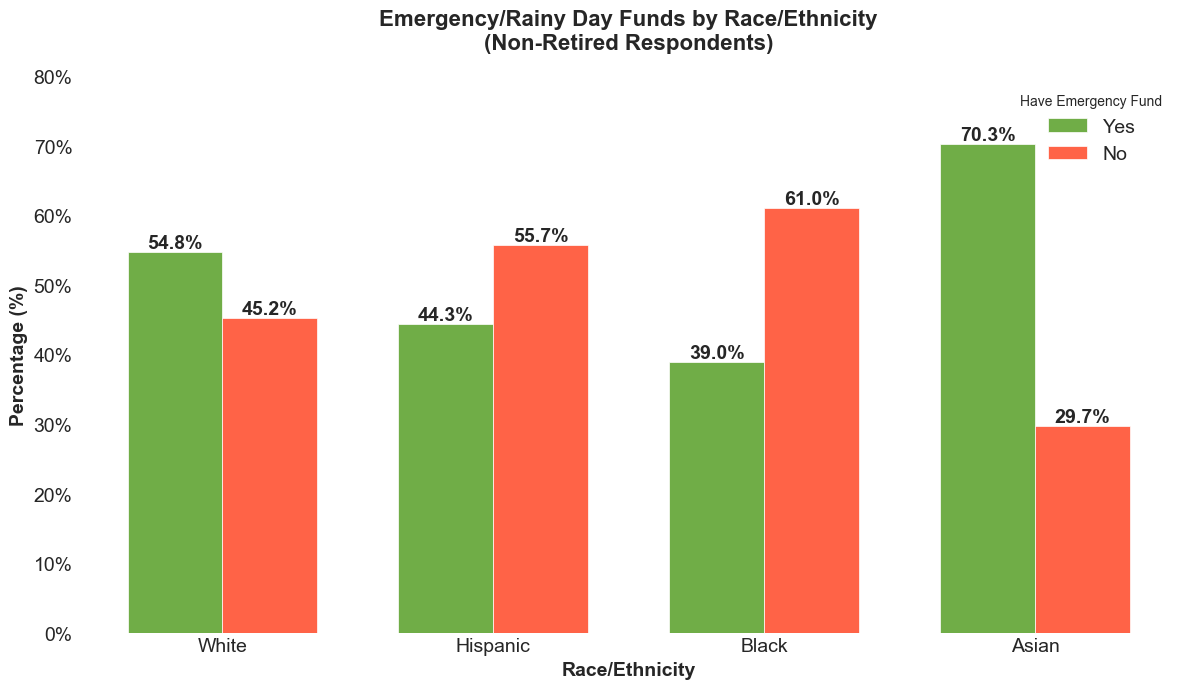


Emergency/Rainy Day Funds by Race/Ethnicity:
EF1         Yes    No
race_5cat            
White     54.80 45.20
Hispanic  44.30 55.70
Black     39.00 61.00
Asian     70.30 29.70

Total respondents included: 7,858


In [67]:
# Chart 3: Race/Ethnicity vs Emergency Savings Fund (EF1)
# Filter for valid EF1 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart3 = df[df['race_5cat'].isin(race_groups) & df['EF1'].notna()].copy()

# Create crosstab with percentages
ef1_by_race = pd.crosstab(df_chart3['race_5cat'], df_chart3['EF1'], normalize='index') * 100

# Define the order of EF1 categories
ef1_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
ef1_order = [cat for cat in ef1_order if cat in ef1_by_race.columns]
ef1_by_race = ef1_by_race[ef1_order]

# Reindex to ensure race groups are in order
ef1_by_race = ef1_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.35

# Define simple, distinguishable colors
colors = ['#70AD47', '#FF6347']  # Green for "Yes", Red-orange for "No"

# Create bars for each EF1 category
bars = []
for i, category in enumerate(ef1_order):
    offset = (i - len(ef1_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ef1_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Emergency/Rainy Day Funds by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Have Emergency Fund')

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-80%
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nEmergency/Rainy Day Funds by Race/Ethnicity:")
print("="*60)
print(ef1_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart3):,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/3751185490.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart4[df_chart4[var].notna()].groupby('race_5cat').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/3751185490.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart4[df_chart4[var].notna()].groupby('race_5cat').apply(
/var/folde

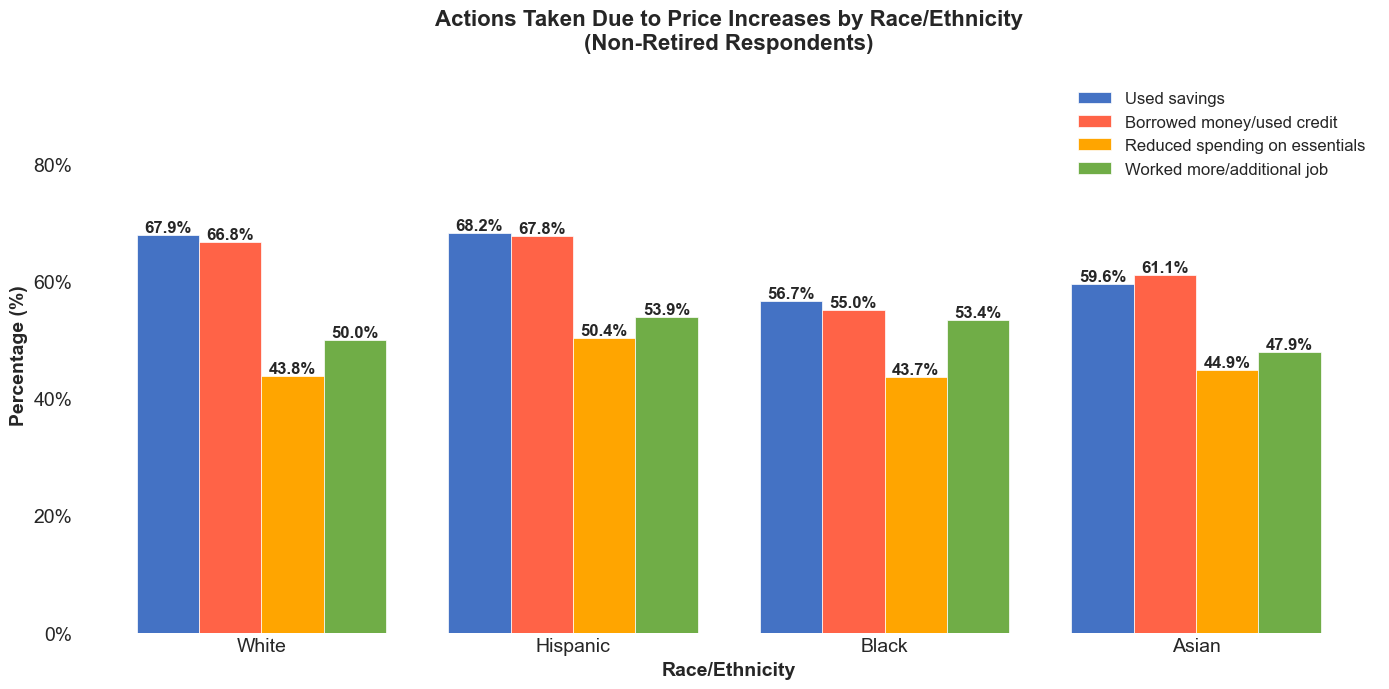


Actions Taken Due to Price Increases by Race/Ethnicity:
           Used savings  Borrowed money/used credit  Reduced spending on essentials  Worked more/additional job
race_5cat                                                                                                      
White             67.90                       66.80                           43.80                       50.00
Hispanic          68.20                       67.80                           50.40                       53.90
Black             56.70                       55.00                           43.70                       53.40
Asian             59.60                       61.10                           44.90                       47.90

Total respondents: 7,858


In [68]:
# Chart 4: Race/Ethnicity vs Actions Taken Due to Price Increases (INF3 series)
# Filter for valid INF3 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Define the INF3 variables to include
inf3_vars = {
    'INF3_a': 'Used savings',
    'INF3_b': 'Borrowed money/used credit',
    'INF3_c': 'Reduced spending on essentials',
    'INF3_e': 'Worked more/additional job'
}

# Filter data for race groups
df_chart4 = df[df['race_5cat'].isin(race_groups)].copy()

# Calculate percentages for each action by race group
inf3_by_race = pd.DataFrame()

for var, label in inf3_vars.items():
    if var in df_chart4.columns:
        pct_by_race = df_chart4[df_chart4[var].notna()].groupby('race_5cat').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        inf3_by_race[label] = pct_by_race

# Reindex to ensure race groups are in order
inf3_by_race = inf3_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.2

# Define simple, distinguishable colors
colors = ['#4472C4', '#FF6347', '#FFA500', '#70AD47']  # Blue, Red-orange, Orange, Green

# Create bars for each action category
bars = []
action_labels = list(inf3_vars.values())

for i, action in enumerate(action_labels):
    if action in inf3_by_race.columns:
        offset = (i - len(action_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, inf3_by_race[action], width, 
                     label=action, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Actions Taken Due to Price Increases by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nActions Taken Due to Price Increases by Race/Ethnicity:")
print("="*60)
print(inf3_by_race.round(1).to_string())
print(f"\nTotal respondents: {len(df_chart4):,}")

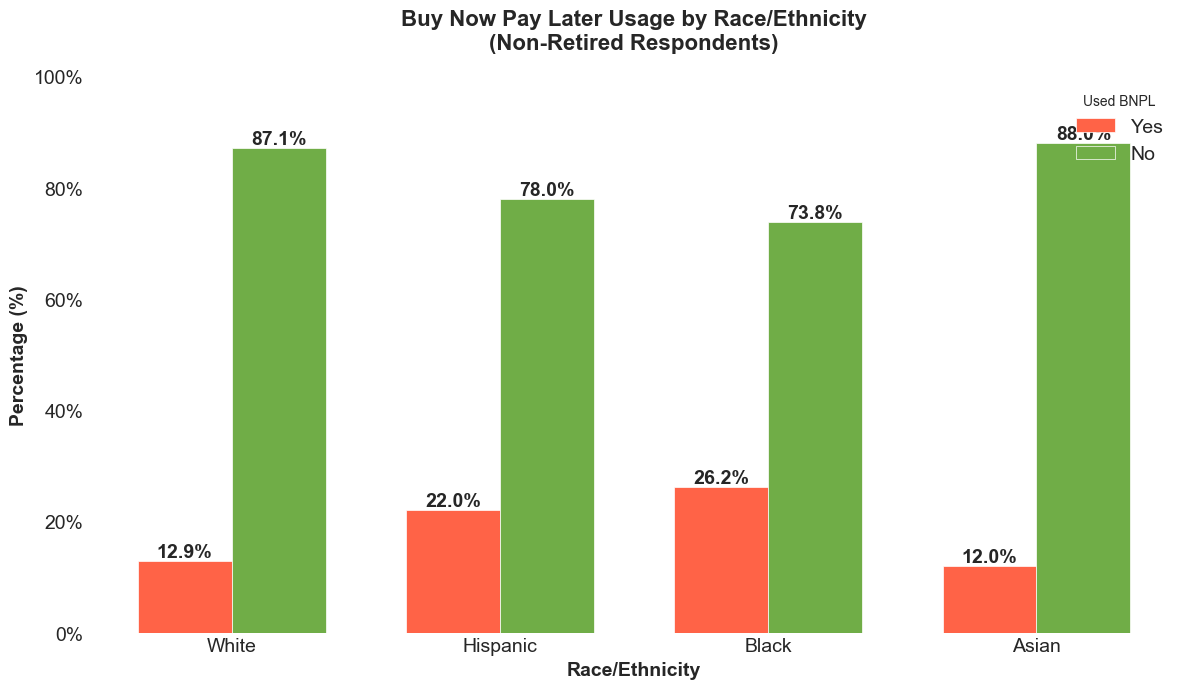


Buy Now Pay Later Usage by Race/Ethnicity:
BNPL1       Yes    No
race_5cat            
White     12.90 87.10
Hispanic  22.00 78.00
Black     26.20 73.80
Asian     12.00 88.00

Total respondents included: 7,858


In [69]:
# Chart 6: Race/Ethnicity vs Buy Now Pay Later Usage (BNPL1)
# Filter for valid BNPL1 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart6 = df[df['race_5cat'].isin(race_groups) & df['BNPL1'].notna()].copy()

# Create crosstab with percentages
bnpl1_by_race = pd.crosstab(df_chart6['race_5cat'], df_chart6['BNPL1'], normalize='index') * 100

# Define the order of BNPL1 categories
bnpl1_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
bnpl1_order = [cat for cat in bnpl1_order if cat in bnpl1_by_race.columns]
bnpl1_by_race = bnpl1_by_race[bnpl1_order]

# Reindex to ensure race groups are in order
bnpl1_by_race = bnpl1_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.35

# Define simple, distinguishable colors
colors = ['#FF6347', '#70AD47']  # Red-orange for "Yes", Green for "No"

# Create bars for each BNPL1 category
bars = []
for i, category in enumerate(bnpl1_order):
    offset = (i - len(bnpl1_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, bnpl1_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Buy Now Pay Later Usage by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Used BNPL', bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-100%
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nBuy Now Pay Later Usage by Race/Ethnicity:")
print("="*60)
print(bnpl1_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart6):,}")

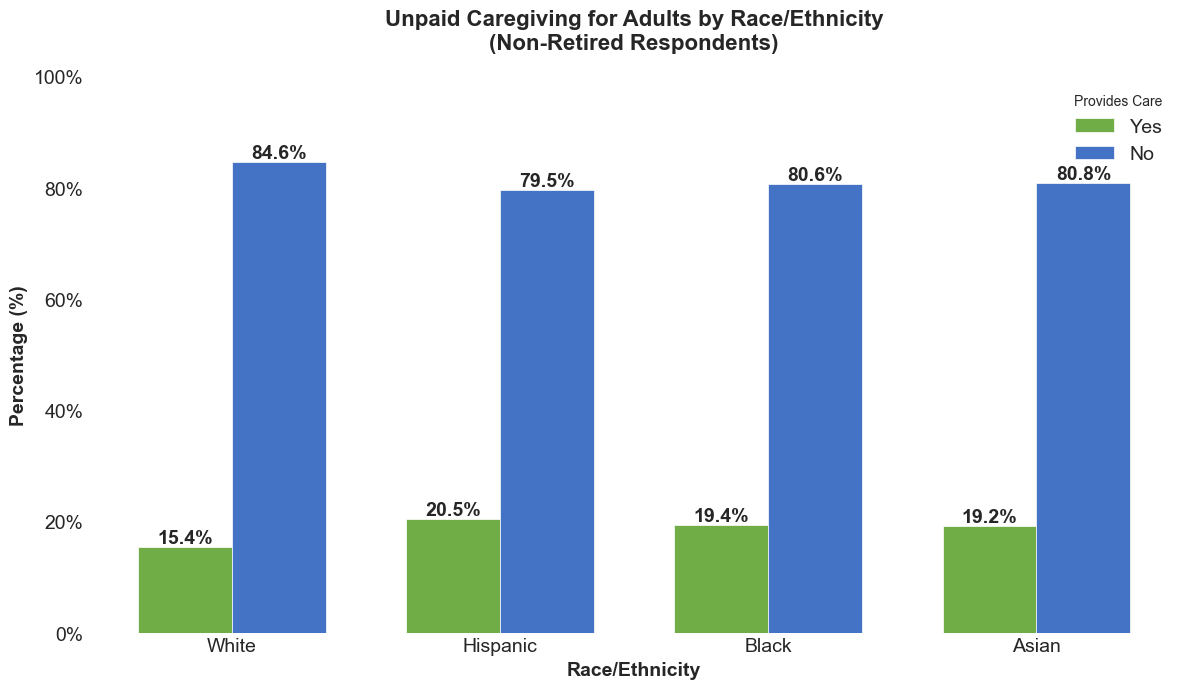


Unpaid Caregiving for Adults by Race/Ethnicity:
CG4         Yes    No
race_5cat            
White     15.40 84.60
Hispanic  20.50 79.50
Black     19.40 80.60
Asian     19.20 80.80

Total respondents included: 7,858


In [70]:
# Chart 7: Race/Ethnicity vs Unpaid Caregiving for Adults (CG4)
# Filter for valid CG4 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart7 = df[df['race_5cat'].isin(race_groups) & df['CG4'].notna()].copy()

# Create crosstab with percentages
cg4_by_race = pd.crosstab(df_chart7['race_5cat'], df_chart7['CG4'], normalize='index') * 100

# Define the order of CG4 categories
cg4_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
cg4_order = [cat for cat in cg4_order if cat in cg4_by_race.columns]
cg4_by_race = cg4_by_race[cg4_order]

# Reindex to ensure race groups are in order
cg4_by_race = cg4_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.35

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4']  # Green for "Yes", Blue for "No"

# Create bars for each CG4 category
bars = []
for i, category in enumerate(cg4_order):
    offset = (i - len(cg4_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, cg4_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Unpaid Caregiving for Adults by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Provides Care', bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-100%
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nUnpaid Caregiving for Adults by Race/Ethnicity:")
print("="*60)
print(cg4_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart7):,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/3684810269.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart8[df_chart8[var].notna()].groupby('race_5cat').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/3684810269.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart8[df_chart8[var].notna()].groupby('race_5cat').apply(
/var/folde

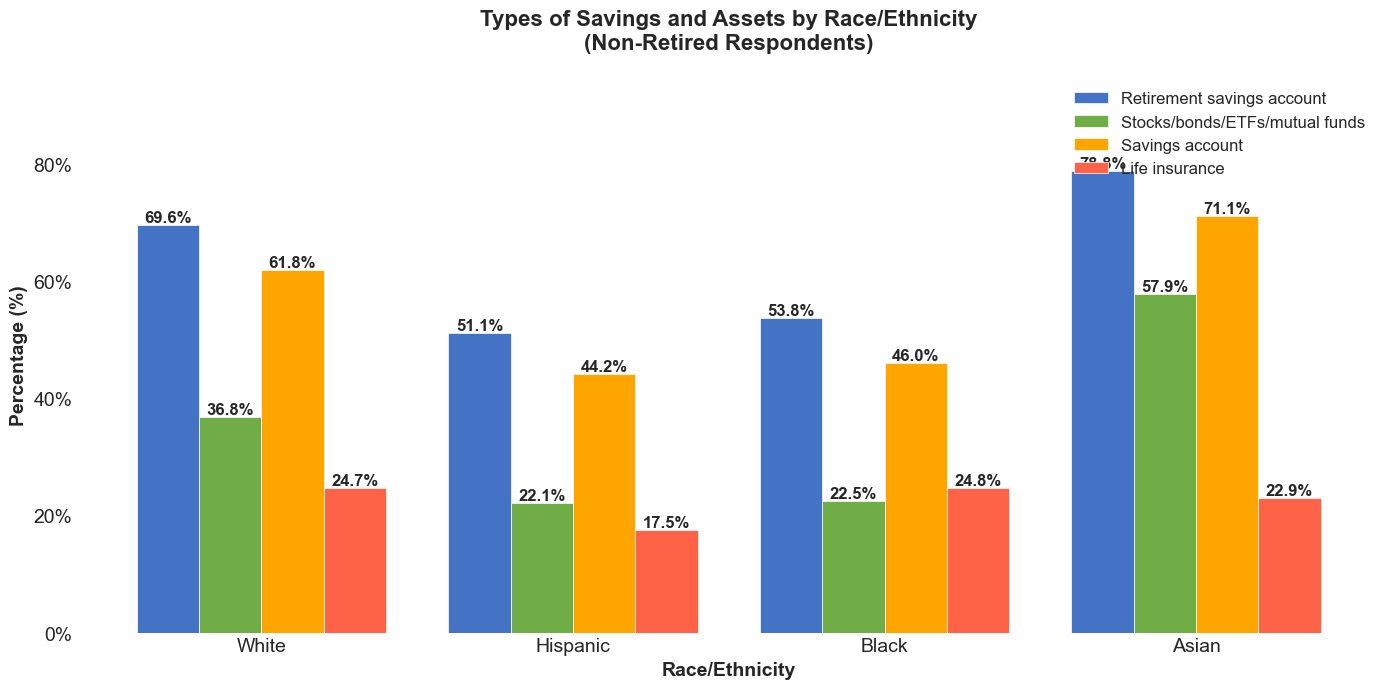


Types of Savings and Assets by Race/Ethnicity:
           Retirement savings account  Stocks/bonds/ETFs/mutual funds  Savings account  Life insurance
race_5cat                                                                                             
White                           69.60                           36.80            61.80           24.70
Hispanic                        51.10                           22.10            44.20           17.50
Black                           53.80                           22.50            46.00           24.80
Asian                           78.80                           57.90            71.10           22.90

Total respondents: 7,858


In [71]:
# Chart 8: Race/Ethnicity vs Types of Savings/Assets (K21 series)
# Filter for valid K21 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Define the K21 variables to include
k21_vars = {
    'K21_a': 'Retirement savings account',
    'K21_c': 'Stocks/bonds/ETFs/mutual funds',
    'K21_d': 'Savings account',
    'K21_e': 'Life insurance'
}

# Filter data for race groups
df_chart8 = df[df['race_5cat'].isin(race_groups)].copy()

# Calculate percentages for each asset type by race group
k21_by_race = pd.DataFrame()

for var, label in k21_vars.items():
    if var in df_chart8.columns:
        pct_by_race = df_chart8[df_chart8[var].notna()].groupby('race_5cat').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        k21_by_race[label] = pct_by_race

# Reindex to ensure race groups are in order
k21_by_race = k21_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.2

# Define simple, distinguishable colors
colors = ['#4472C4', '#70AD47', '#FFA500', '#FF6347']  # Blue, Green, Orange, Red-orange

# Create bars for each asset category
bars = []
asset_labels = list(k21_vars.values())

for i, asset in enumerate(asset_labels):
    if asset in k21_by_race.columns:
        offset = (i - len(asset_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, k21_by_race[asset], width, 
                     label=asset, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Types of Savings and Assets by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTypes of Savings and Assets by Race/Ethnicity:")
print("="*60)
print(k21_by_race.round(1).to_string())
print(f"\nTotal respondents: {len(df_chart8):,}")

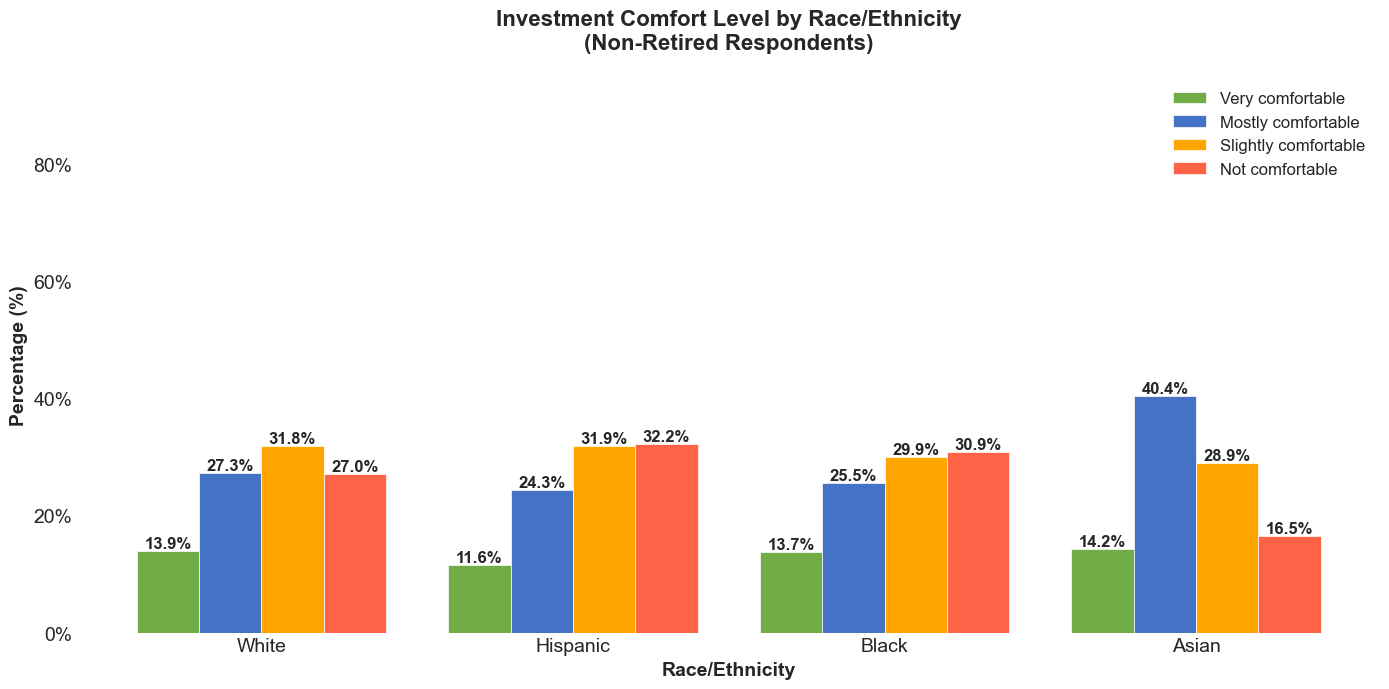


Investment Comfort Level by Race/Ethnicity:
DC4        Very comfortable  Mostly comfortable  Slightly comfortable  Not comfortable
race_5cat                                                                             
White                 13.90               27.30                 31.80            27.00
Hispanic              11.60               24.30                 31.90            32.20
Black                 13.70               25.50                 29.90            30.90
Asian                 14.20               40.40                 28.90            16.50

Total respondents included: 7,858


In [72]:
# Chart 9: Race/Ethnicity vs Investment Comfort Level (DC4)
# Filter for valid DC4 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart9 = df[df['race_5cat'].isin(race_groups) & df['DC4'].notna()].copy()

# Create crosstab with percentages
dc4_by_race = pd.crosstab(df_chart9['race_5cat'], df_chart9['DC4'], normalize='index') * 100

# Define the order of DC4 categories (from most to least comfortable)
dc4_order = ['Very comfortable', 'Mostly comfortable', 'Slightly comfortable', 'Not comfortable']

# Filter to only include categories that exist in the data
dc4_order = [cat for cat in dc4_order if cat in dc4_by_race.columns]
dc4_by_race = dc4_by_race[dc4_order]

# Reindex to ensure race groups are in order
dc4_by_race = dc4_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.2

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4', '#FFA500', '#FF6347']  # Green, Blue, Orange, Red-orange

# Create bars for each DC4 category
bars = []
for i, category in enumerate(dc4_order):
    offset = (i - len(dc4_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, dc4_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Investment Comfort Level by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nInvestment Comfort Level by Race/Ethnicity:")
print("="*60)
print(dc4_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart9):,}")

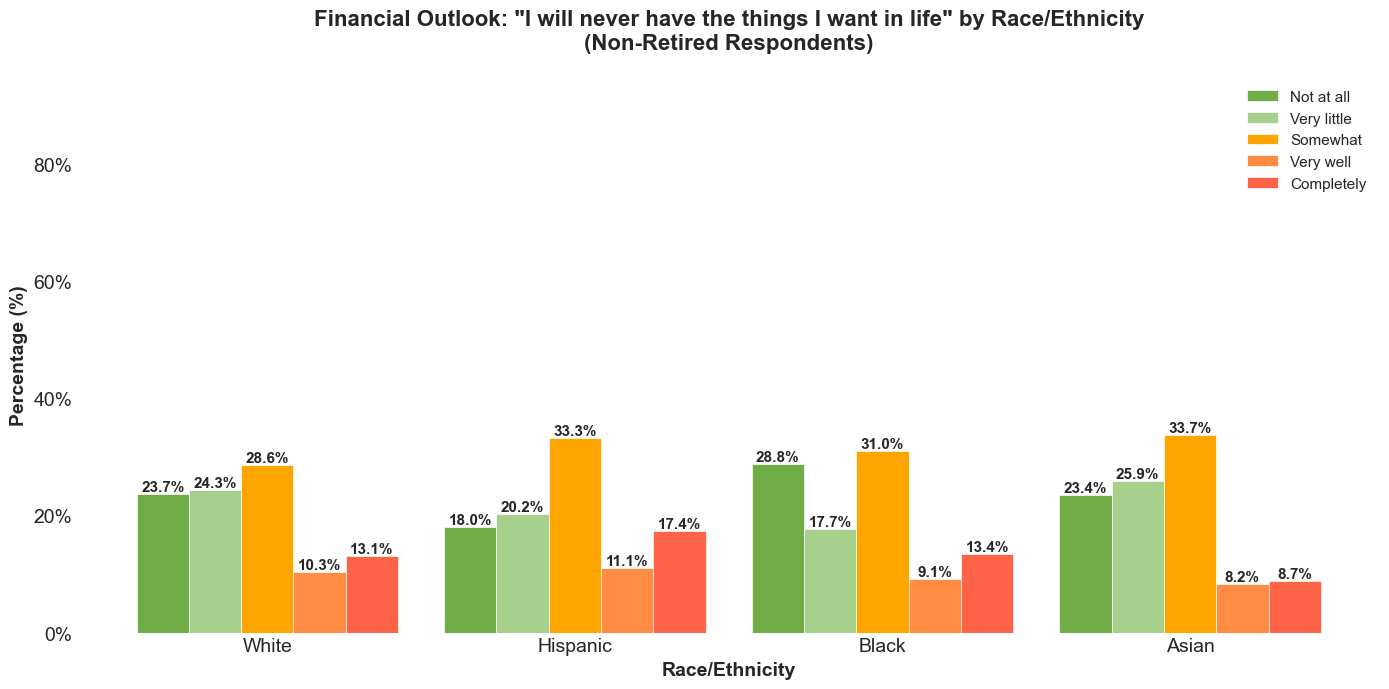


Financial Outlook by Race/Ethnicity:
B0_a       Not at all  Very little  Somewhat  Very well  Completely
race_5cat                                                          
White           23.70        24.30     28.60      10.30       13.10
Hispanic        18.00        20.20     33.30      11.10       17.40
Black           28.80        17.70     31.00       9.10       13.40
Asian           23.40        25.90     33.70       8.20        8.70

Total respondents included: 7,858


In [73]:
# Chart 10: Race/Ethnicity vs Financial Outlook (B0_a)
# Filter for valid B0_a responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart10 = df[df['race_5cat'].isin(race_groups) & df['B0_a'].notna()].copy()

# Create crosstab with percentages
b0a_by_race = pd.crosstab(df_chart10['race_5cat'], df_chart10['B0_a'], normalize='index') * 100

# Define the order of B0_a categories (from most positive to most negative)
b0a_order = ['Not at all', 'Very little', 'Somewhat', 'Very well', 'Completely']

# Filter to only include categories that exist in the data
b0a_order = [cat for cat in b0a_order if cat in b0a_by_race.columns]
b0a_by_race = b0a_by_race[b0a_order]

# Reindex to ensure race groups are in order
b0a_by_race = b0a_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.17

# Define simple, distinguishable colors (green for positive, red-orange for negative)
colors = ['#70AD47', '#A8D08D', '#FFA500', '#FF8C42', '#FF6347']

# Create bars for each B0_a category
bars = []
for i, category in enumerate(b0a_order):
    offset = (i - len(b0a_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, b0a_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Financial Outlook: "I will never have the things I want in life" by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=11, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFinancial Outlook by Race/Ethnicity:")
print("="*60)
print(b0a_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart10):,}")

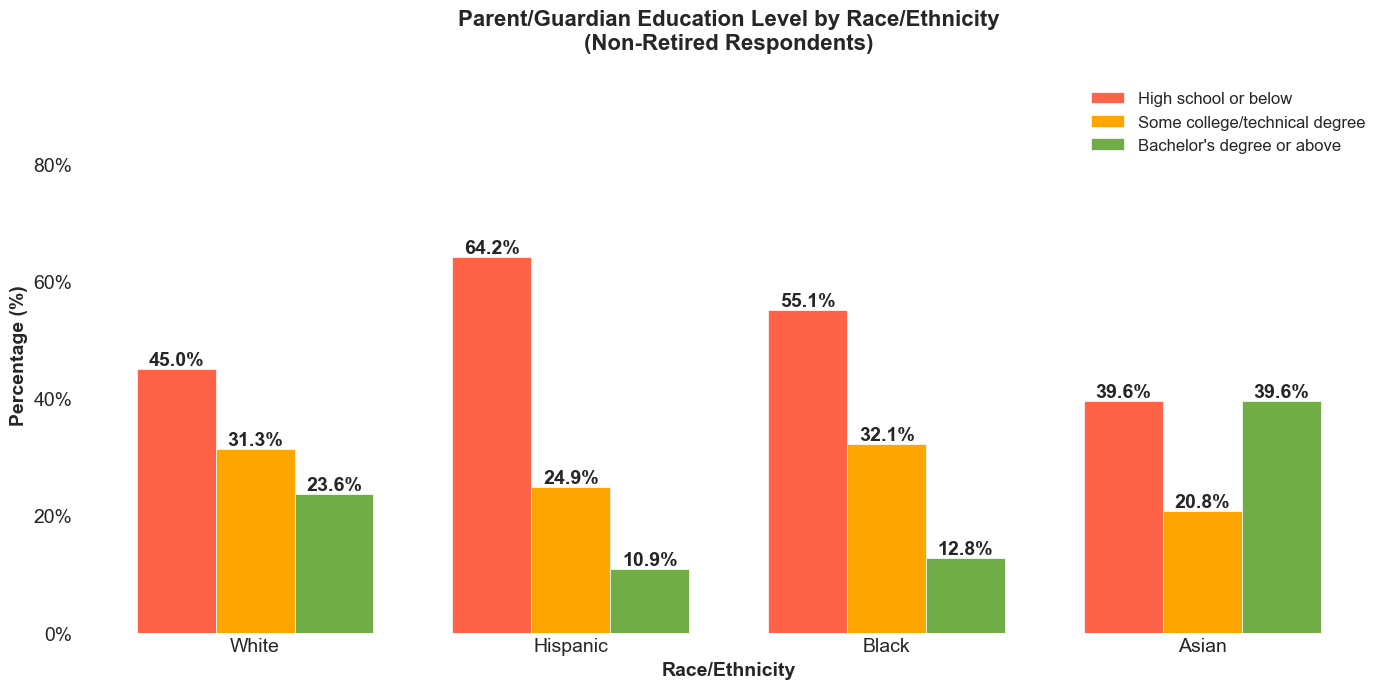


Parent/Guardian Education Level by Race/Ethnicity:
CH2A_grouped  High school or below  Some college/technical degree  Bachelor's degree or above
race_5cat                                                                                    
White                        45.00                          31.30                       23.60
Hispanic                     64.20                          24.90                       10.90
Black                        55.10                          32.10                       12.80
Asian                        39.60                          20.80                       39.60

Total respondents included: 5,952


In [74]:
# Chart 11: Race/Ethnicity vs Parent/Guardian Education Level (CH2A)
# Filter for valid CH2A responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart11 = df[df['race_5cat'].isin(race_groups) & df['CH2A'].notna()].copy()

# Create education categories based on the CH2A codes
def categorize_parent_education(value):
    if value in ['Less than high school degree', 'High school degree or GED']:
        return 'High school or below'
    elif value in ['Some college but no degree', 'Certificate or technical degree', 'Associate degree']:
        return 'Some college/technical degree'
    elif value in ["Bachelor's degree", 'Graduate degree']:
        return "Bachelor's degree or above"
    else:
        return None  # Exclude Don't know, Refused, and blanks

df_chart11['CH2A_grouped'] = df_chart11['CH2A'].apply(categorize_parent_education)

# Filter out None values (Don't know, Refused, blanks)
df_chart11 = df_chart11[df_chart11['CH2A_grouped'].notna()].copy()

# Create crosstab with percentages
ch2a_by_race = pd.crosstab(df_chart11['race_5cat'], df_chart11['CH2A_grouped'], normalize='index') * 100

# Define the order of CH2A categories (from lowest to highest education)
ch2a_order = ['High school or below', 'Some college/technical degree', "Bachelor's degree or above"]

# Filter to only include categories that exist in the data
ch2a_order = [cat for cat in ch2a_order if cat in ch2a_by_race.columns]
ch2a_by_race = ch2a_by_race[ch2a_order]

# Reindex to ensure race groups are in order
ch2a_by_race = ch2a_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.25

# Define simple, distinguishable colors
colors = ['#FF6347', '#FFA500', '#70AD47']  # Red-orange, Orange, Green

# Create bars for each education category
bars = []
for i, category in enumerate(ch2a_order):
    offset = (i - len(ch2a_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ch2a_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Parent/Guardian Education Level by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nParent/Guardian Education Level by Race/Ethnicity:")
print("="*60)
print(ch2a_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart11):,}")

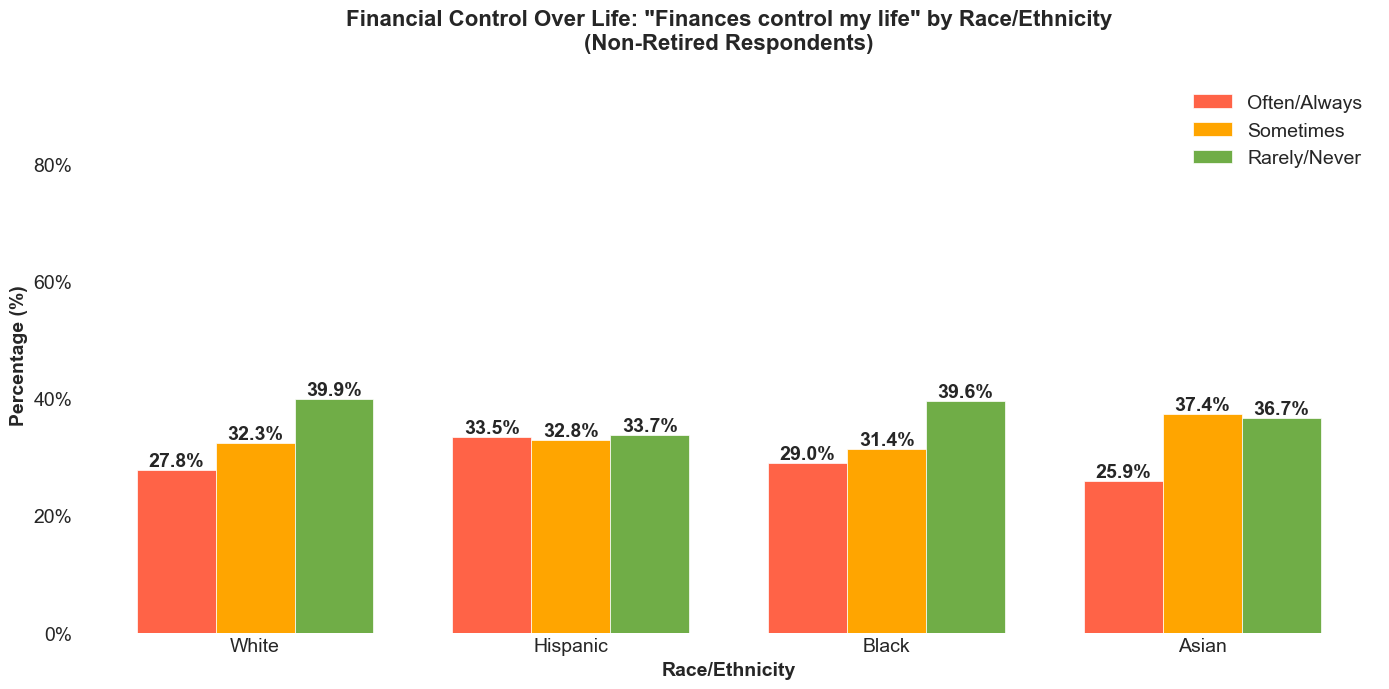


Financial Control Over Life by Race/Ethnicity:
B1_b_grouped  Often/Always  Sometimes  Rarely/Never
race_5cat                                          
White                27.80      32.30         39.90
Hispanic             33.50      32.80         33.70
Black                29.00      31.40         39.60
Asian                25.90      37.40         36.70

Total respondents included: 7,858


In [75]:
# Chart 13: Race/Ethnicity vs Financial Control Over Life (B1_b)
# Filter for valid B1_b responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart13 = df[df['race_5cat'].isin(race_groups) & df['B1_b'].notna()].copy()

# Create combined categories
def categorize_financial_control(value):
    if value in ['Always', 'Often']:
        return 'Often/Always'
    elif value == 'Sometimes':
        return 'Sometimes'
    elif value in ['Rarely', 'Never']:
        return 'Rarely/Never'
    else:
        return None

df_chart13['B1_b_grouped'] = df_chart13['B1_b'].apply(categorize_financial_control)

# Filter out None values
df_chart13 = df_chart13[df_chart13['B1_b_grouped'].notna()].copy()

# Create crosstab with percentages
b1b_by_race = pd.crosstab(df_chart13['race_5cat'], df_chart13['B1_b_grouped'], normalize='index') * 100

# Define the order of B1_b categories (from most to least stressed)
b1b_order = ['Often/Always', 'Sometimes', 'Rarely/Never']

# Filter to only include categories that exist in the data
b1b_order = [cat for cat in b1b_order if cat in b1b_by_race.columns]
b1b_by_race = b1b_by_race[b1b_order]

# Reindex to ensure race groups are in order
b1b_by_race = b1b_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.25

# Define simple, distinguishable colors (red-orange for high stress, green for low stress)
colors = ['#FF6347', '#FFA500', '#70AD47']  # Red-orange, Orange, Green

# Create bars for each B1_b category
bars = []
for i, category in enumerate(b1b_order):
    offset = (i - len(b1b_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, b1b_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Financial Control Over Life: "Finances control my life" by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFinancial Control Over Life by Race/Ethnicity:")
print("="*60)
print(b1b_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart13):,}")

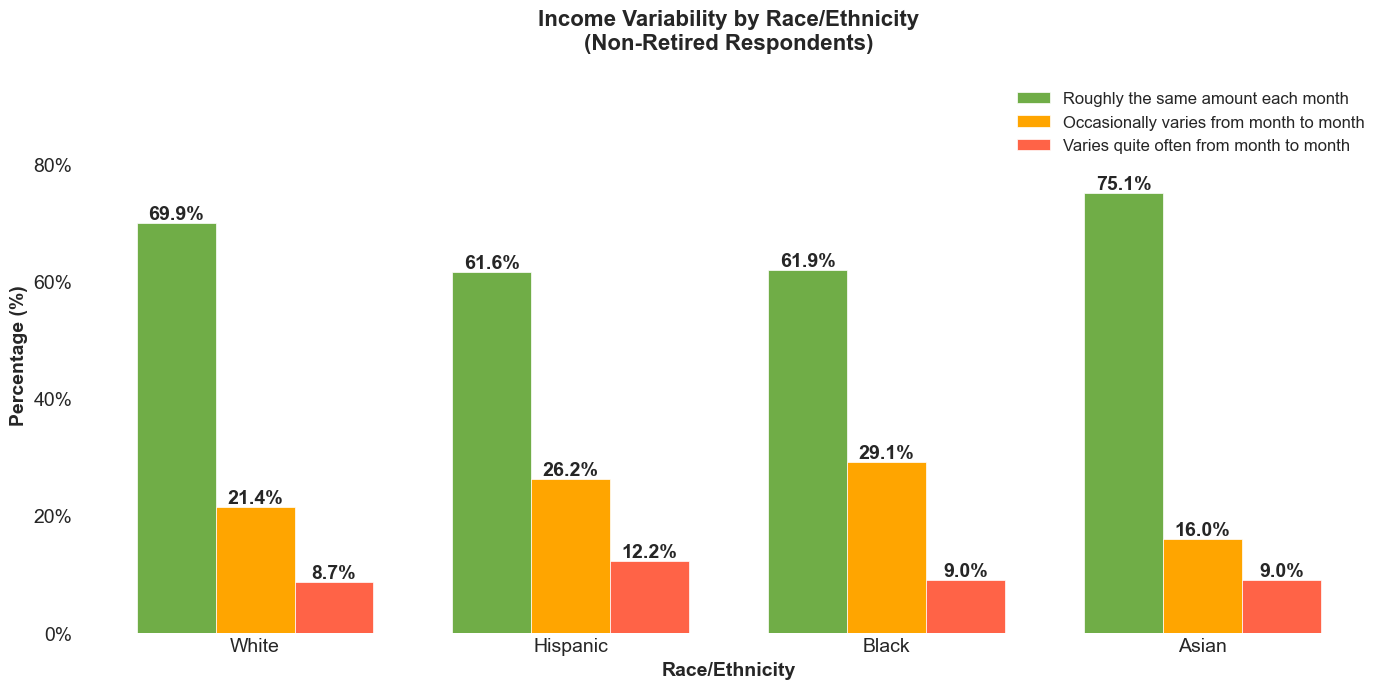


Income Variability by Race/Ethnicity:
I9         Roughly the same amount each month  Occasionally varies from month to month  Varies quite often from month to month
race_5cat                                                                                                                     
White                                   69.90                                    21.40                                    8.70
Hispanic                                61.60                                    26.20                                   12.20
Black                                   61.90                                    29.10                                    9.00
Asian                                   75.10                                    16.00                                    9.00

Total respondents included: 7,858


In [76]:
# Chart 15: Race/Ethnicity vs Income Variability (I9)
# Filter for valid I9 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart15 = df[df['race_5cat'].isin(race_groups) & df['I9'].notna()].copy()

# Create crosstab with percentages
i9_by_race = pd.crosstab(df_chart15['race_5cat'], df_chart15['I9'], normalize='index') * 100

# Define the order of I9 categories (from most stable to least stable)
i9_order = ['Roughly the same amount each month', 'Occasionally varies from month to month', 'Varies quite often from month to month']

# Filter to only include categories that exist in the data
i9_order = [cat for cat in i9_order if cat in i9_by_race.columns]
i9_by_race = i9_by_race[i9_order]

# Reindex to ensure race groups are in order
i9_by_race = i9_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.25

# Define simple, distinguishable colors (green for stable, red-orange for unstable)
colors = ['#70AD47', '#FFA500', '#FF6347']  # Green, Orange, Red-orange

# Create bars for each I9 category
bars = []
for i, category in enumerate(i9_order):
    offset = (i - len(i9_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, i9_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Income Variability by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nIncome Variability by Race/Ethnicity:")
print("="*60)
print(i9_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart15):,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/2016221041.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart16[df_chart16[var].notna()].groupby('race_5cat').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/2016221041.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart16[df_chart16[var].notna()].groupby('race_5cat').apply(
/var/f

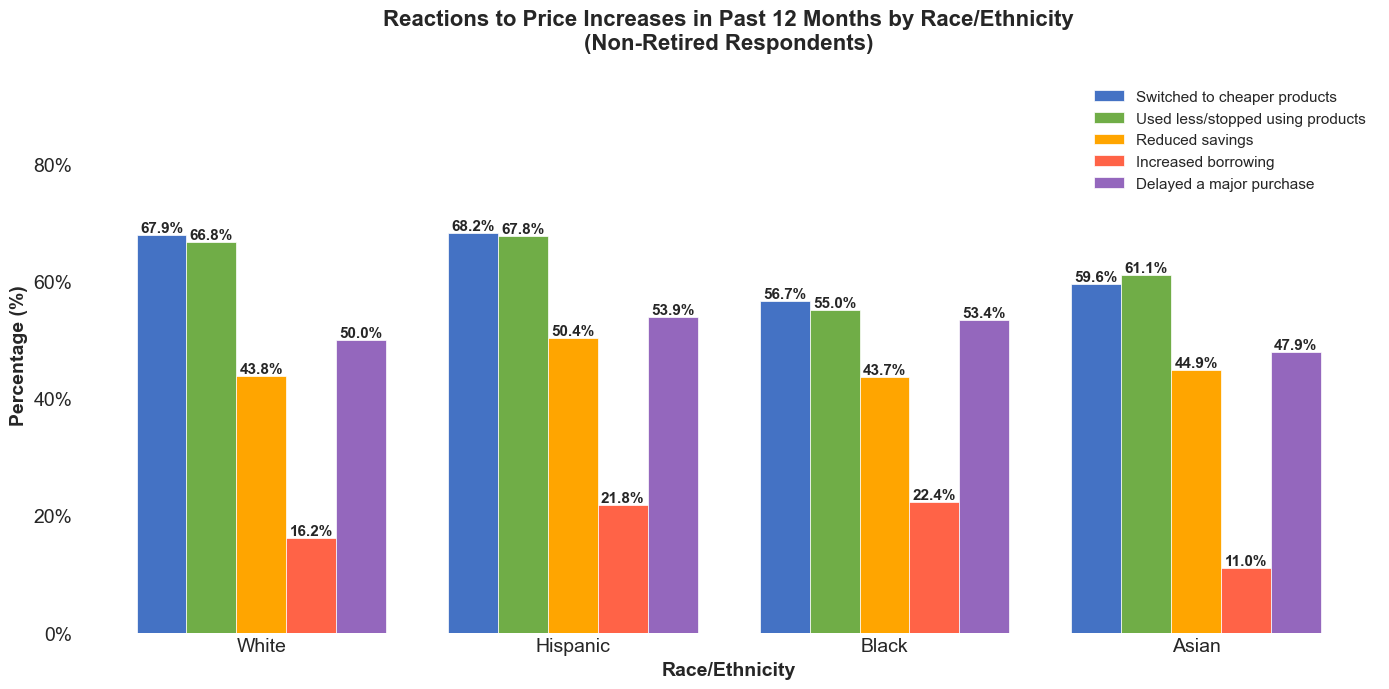


Reactions to Price Increases by Race/Ethnicity:
           Switched to cheaper products  Used less/stopped using products  Reduced savings  Increased borrowing  Delayed a major purchase
race_5cat                                                                                                                                
White                             67.90                             66.80            43.80                16.20                     50.00
Hispanic                          68.20                             67.80            50.40                21.80                     53.90
Black                             56.70                             55.00            43.70                22.40                     53.40
Asian                             59.60                             61.10            44.90                11.00                     47.90

Total respondents: 7,858


In [77]:
# Chart 16: Race/Ethnicity vs Reactions to Price Increases (INF3 series - alternative set)
# Filter for valid INF3 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Define the INF3 variables to include (price increase reactions)
inf3_reaction_vars = {
    'INF3_a': 'Switched to cheaper products',
    'INF3_b': 'Used less/stopped using products',
    'INF3_c': 'Reduced savings',
    'INF3_d': 'Increased borrowing',
    'INF3_e': 'Delayed a major purchase'
}

# Filter data for race groups
df_chart16 = df[df['race_5cat'].isin(race_groups)].copy()

# Calculate percentages for each reaction by race group
inf3_reaction_by_race = pd.DataFrame()

for var, label in inf3_reaction_vars.items():
    if var in df_chart16.columns:
        pct_by_race = df_chart16[df_chart16[var].notna()].groupby('race_5cat').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        inf3_reaction_by_race[label] = pct_by_race

# Reindex to ensure race groups are in order
inf3_reaction_by_race = inf3_reaction_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.16

# Define simple, distinguishable colors
colors = ['#4472C4', '#70AD47', '#FFA500', '#FF6347', '#9467BD']  # Blue, Green, Orange, Red-orange, Purple

# Create bars for each reaction category
bars = []
reaction_labels = list(inf3_reaction_vars.values())

for i, reaction in enumerate(reaction_labels):
    if reaction in inf3_reaction_by_race.columns:
        offset = (i - len(reaction_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, inf3_reaction_by_race[reaction], width, 
                     label=reaction, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Reactions to Price Increases in Past 12 Months by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=11, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nReactions to Price Increases by Race/Ethnicity:")
print("="*60)
print(inf3_reaction_by_race.round(1).to_string())
print(f"\nTotal respondents: {len(df_chart16):,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/2340870025.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart17[df_chart17[var].notna()].groupby('race_5cat').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_50838/2340870025.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_race = df_chart17[df_chart17[var].notna()].groupby('race_5cat').apply(
/var/f

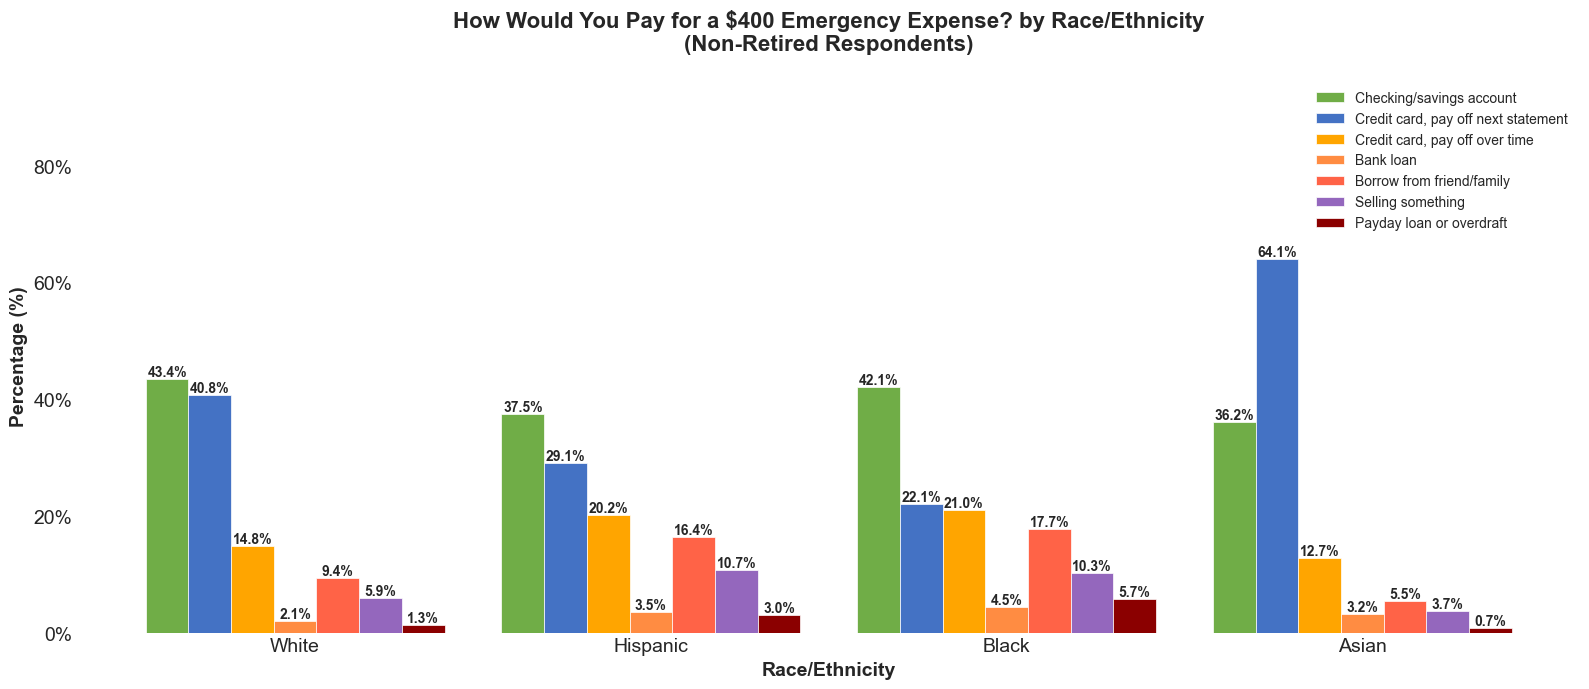


$400 Emergency Expense Payment Methods by Race/Ethnicity:
           Checking/savings account  Credit card, pay off next statement  Credit card, pay off over time  Bank loan  Borrow from friend/family  Selling something  Payday loan or overdraft
race_5cat                                                                                                                                                                                  
White                         43.40                                40.80                           14.80       2.10                       9.40               5.90                      1.30
Hispanic                      37.50                                29.10                           20.20       3.50                      16.40              10.70                      3.00
Black                         42.10                                22.10                           21.00       4.50                      17.70              10.30                      5.70
A

In [78]:
# Chart 17: Race/Ethnicity vs $400 Emergency Expense Payment Methods (EF3 series)
# Filter for valid EF3 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Define the EF3 variables to include
ef3_vars = {
    'EF3_c': 'Checking/savings account',
    'EF3_a': 'Credit card, pay off next statement',
    'EF3_b': 'Credit card, pay off over time',
    'EF3_d': 'Bank loan',
    'EF3_e': 'Borrow from friend/family',
    'EF3_g': 'Selling something',
    'EF3_f': 'Payday loan or overdraft'
}

# Filter data for race groups
df_chart17 = df[df['race_5cat'].isin(race_groups)].copy()

# Calculate percentages for each payment method by race group
ef3_by_race = pd.DataFrame()

for var, label in ef3_vars.items():
    if var in df_chart17.columns:
        pct_by_race = df_chart17[df_chart17[var].notna()].groupby('race_5cat').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        ef3_by_race[label] = pct_by_race

# Reindex to ensure race groups are in order
ef3_by_race = ef3_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(16, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.12

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4', '#FFA500', '#FF8C42', '#FF6347', '#9467BD', '#8B0000']  
# Green, Blue, Orange, Light red-orange, Red-orange, Purple, Dark red

# Create bars for each payment method category
bars = []
payment_labels = list(ef3_vars.values())

for i, payment in enumerate(payment_labels):
    if payment in ef3_by_race.columns:
        offset = (i - len(payment_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, ef3_by_race[payment], width, 
                     label=payment, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('How Would You Pay for a $400 Emergency Expense? by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=10, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n$400 Emergency Expense Payment Methods by Race/Ethnicity:")
print("="*60)
print(ef3_by_race.round(1).to_string())
print(f"\nTotal respondents: {len(df_chart17):,}")

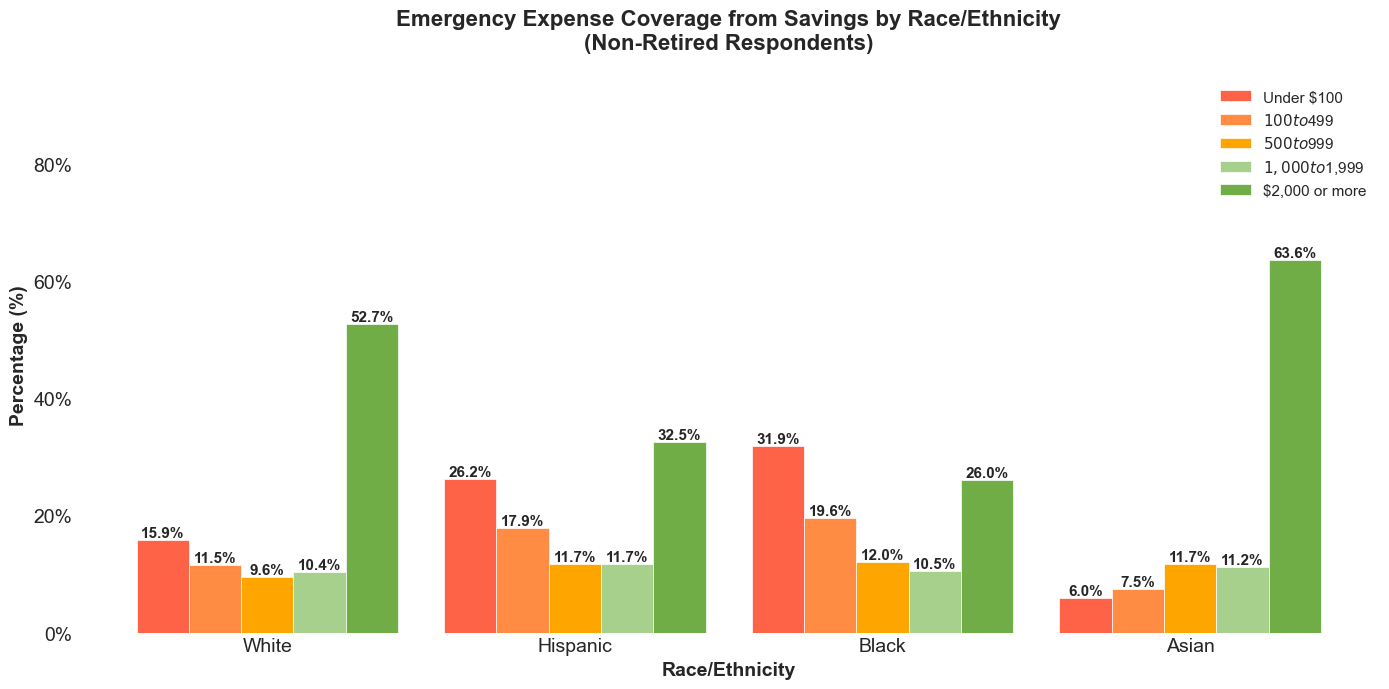


Emergency Expense Coverage from Savings by Race/Ethnicity:
EF7        Under $100  $100 to $499  $500 to $999  $1,000 to $1,999  $2,000 or more
race_5cat                                                                          
White           15.90         11.50          9.60             10.40           52.70
Hispanic        26.20         17.90         11.70             11.70           32.50
Black           31.90         19.60         12.00             10.50           26.00
Asian            6.00          7.50         11.70             11.20           63.60

Total respondents included: 7,858


In [79]:
# Chart 14: Race/Ethnicity vs Emergency Expense Coverage (EF7)
# Filter for valid EF7 responses

# Define racial/ethnic groups
race_groups = ['White', 'Hispanic', 'Black', 'Asian']

# Filter data
df_chart14 = df[df['race_5cat'].isin(race_groups) & df['EF7'].notna()].copy()

# Create crosstab with percentages
ef7_by_race = pd.crosstab(df_chart14['race_5cat'], df_chart14['EF7'], normalize='index') * 100

# Define the order of EF7 categories (from lowest to highest coverage)
ef7_order = ['Under $100', '$100 to $499', '$500 to $999', '$1,000 to $1,999', '$2,000 or more']

# Filter to only include categories that exist in the data
ef7_order = [cat for cat in ef7_order if cat in ef7_by_race.columns]
ef7_by_race = ef7_by_race[ef7_order]

# Reindex to ensure race groups are in order
ef7_by_race = ef7_by_race.reindex(race_groups)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(race_groups))
width = 0.17

# Define simple, distinguishable colors (red-orange for low, green for high)
colors = ['#FF6347', '#FF8C42', '#FFA500', '#A8D08D', '#70AD47']

# Create bars for each EF7 category
bars = []
for i, category in enumerate(ef7_order):
    offset = (i - len(ef7_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ef7_by_race[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Emergency Expense Coverage from Savings by Race/Ethnicity\n(Non-Retired Respondents)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=11, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nEmergency Expense Coverage from Savings by Race/Ethnicity:")
print("="*60)
print(ef7_by_race.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart14):,}")